/tmp/ipykernel_14024/3448016446.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_14024/3448016446.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


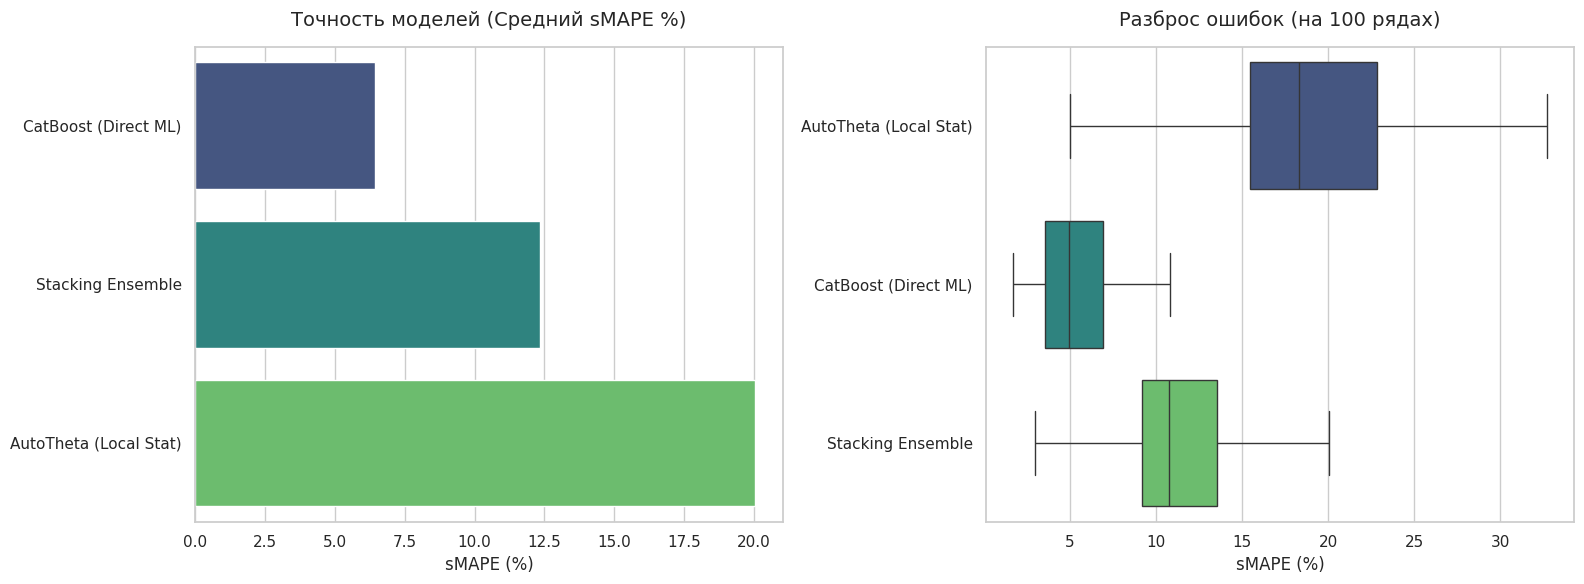

                        mean_smape  std_smape
model                                        
CatBoost (Direct ML)      6.443574   1.748024
Stacking Ensemble        12.358015   1.788057
AutoTheta (Local Stat)   20.026560   2.044923


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('metrics.csv')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_mean = df.groupby('model')['mean_smape'].mean().reset_index()
sns.barplot(
    data=summary_mean.sort_values('mean_smape'),
    x='mean_smape',
    y='model',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Точность моделей (Средний sMAPE %)', fontsize=14, pad=15)
axes[0].set_xlabel('sMAPE (%)')
axes[0].set_ylabel('')

sns.boxplot(
    data=df,
    x='mean_smape',
    y='model',
    ax=axes[1],
    palette='viridis',
    showfliers=False
)
axes[1].set_title('Разброс ошибок (на 100 рядах)', fontsize=14, pad=15)
axes[1].set_xlabel('sMAPE (%)')
axes[1].set_ylabel('')

plt.tight_layout()

plt.savefig('hypothesis5_plots.png', dpi=300)
plt.show()

final_table = df.groupby('model')[['mean_smape', 'std_smape']].mean().sort_values('mean_smape')
print(final_table)